Running on device: cuda
Generating Scatter Data...


Grid (independent): 100%|██████████| 100/100 [01:34<00:00,  1.06it/s]


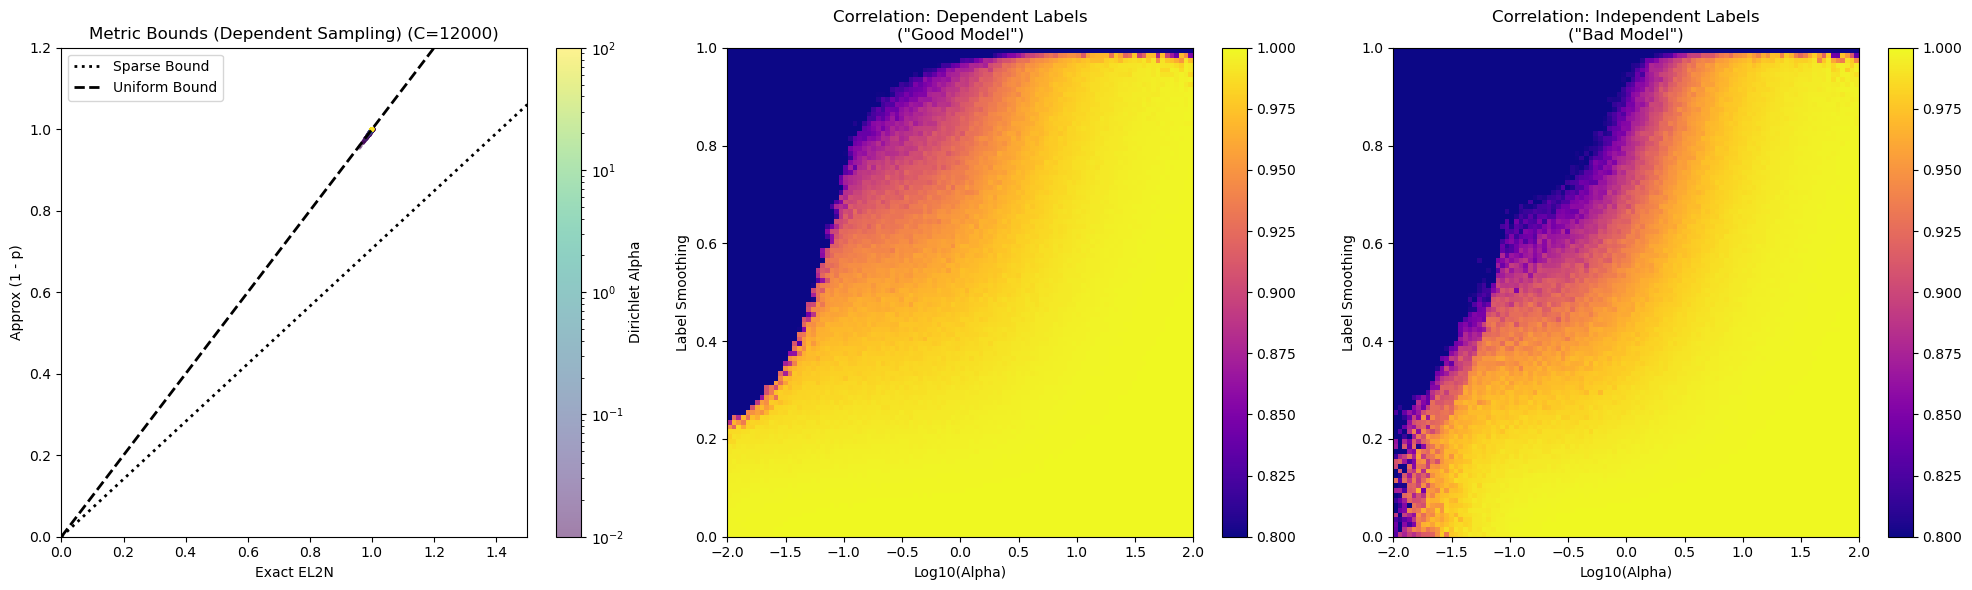

In [ ]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import tqdm

# --- Configuration ---
C = 12000
N_SCATTER_SAMPLES = 5000 
N_GRID_SAMPLES = 2000     
GRID_RES = 100             

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on device: {device}")

# Ranges
alphas_scatter = torch.logspace(-2, 2, N_SCATTER_SAMPLES, device=device)
alphas_grid = torch.logspace(-2, 2, GRID_RES, device=device)
smoothings = torch.linspace(0, 1, GRID_RES, device=device)


# --- JIT-Compiled CUDA Kernels ---
def generate_data_torch(alpha: torch.Tensor, n_samples: int, n_classes: int) -> torch.Tensor:
    concentration = alpha * torch.ones((n_samples, n_classes), device=alpha.device)
    return torch.distributions.Dirichlet(concentration).sample()


@torch.jit.script
def sample_targets_torch(x: torch.Tensor, mode: str) -> torch.Tensor:
    n_samples, n_classes = x.shape
    if mode == 'independent':
        return torch.randint(0, n_classes, (n_samples,), device=x.device)
    # Good Model (Dependent)
    return torch.multinomial(x, 1).squeeze(-1)


@torch.jit.script
def calculate_metrics_torch(x: torch.Tensor, y_indices: torch.Tensor, epsilon: float):
    N, C = x.shape
    row_idx = torch.arange(N, device=x.device)
    
    # 1. Exact EL2N
    x_true = x[row_idx, y_indices]
    x_norm_sq = torch.sum(x**2, dim=1)
    sq_dist = torch.clamp(1.0 + x_norm_sq - 2 * x_true, min=0.0)
    exact_vals = torch.sqrt(sq_dist)
    
    # 2. Approx EL2N
    log_x = torch.log(x + 1e-31)
    
    if epsilon > 0.0:
        w_target = 1.0 - epsilon - (epsilon / (C - 1.0))
        w_rest = epsilon / (C - 1.0)
        ce = - (w_target * log_x[row_idx, y_indices] + w_rest * torch.sum(log_x, dim=1))
    else:
        ce = -log_x[row_idx, y_indices]
        
    approx_vals = 1.0 - torch.exp(-ce)
    
    return exact_vals, approx_vals


def compute_correlation_grid_torch(mode: str):
    corr_map = torch.zeros((GRID_RES, GRID_RES), dtype=torch.float32)
    
    pbar = tqdm(alphas_grid, desc=f"Grid ({mode})")
    for j, alpha in enumerate(pbar):
        for i, eps in enumerate(smoothings):
            x = generate_data_torch(alpha, N_GRID_SAMPLES, C)
            y_idx = sample_targets_torch(x, mode=mode)
            
            exact, approx = calculate_metrics_torch(x, y_idx, eps.item())
            
            # --- Using Built-in torch.corrcoef ---
            # Stack vectors to shape (2, N)
            stack = torch.stack((exact, approx))
            corr_matrix = torch.corrcoef(stack)
            
            # Extract correlation (index [0, 1])
            val = corr_matrix[0, 1]
            
            # Handle NaN (occurs if variance is 0, e.g., constant values)
            if torch.isnan(val):
                corr_map[i, j] = 0.0
            else:
                corr_map[i, j] = val
            
    return corr_map.numpy()


# --- Execution ---

# 1. Scatter Plot Data
print("Generating Scatter Data...")
chunk_size = 100 
n_batches = N_SCATTER_SAMPLES // chunk_size

x_sc_list = []
y_sc_list = []
a_sc_list = []

batch_alphas = torch.logspace(-2, 2, n_batches, device=device)

for a in tqdm(batch_alphas, desc="Scatter Batches"):
    x_batch = generate_data_torch(a, chunk_size, C)
    y_batch = sample_targets_torch(x_batch, mode='dependent')
    e_b, a_b = calculate_metrics_torch(x_batch, y_batch, 0.0)
    
    x_sc_list.append(e_b)
    y_sc_list.append(a_b)
    a_sc_list.append(torch.full((chunk_size,), a.item(), device=device))

x_sc = torch.cat(x_sc_list).cpu().numpy()
y_sc = torch.cat(y_sc_list).cpu().numpy()
a_sc = torch.cat(a_sc_list).cpu().numpy()

# 2. Heatmaps
corr_good = compute_correlation_grid_torch(mode='dependent')
corr_bad = compute_correlation_grid_torch(mode='independent')

# --- Plotting ---
alphas_scatter_np = alphas_scatter.cpu().numpy()
alphas_grid_np = alphas_grid.cpu().numpy()
smoothings_np = smoothings.cpu().numpy()

fig = plt.figure(figsize=(20, 6))

# Panel 1: Scatter
ax1 = plt.subplot(1, 3, 1)
x_line = np.linspace(0, 1.5, 100)
ax1.plot(x_line, x_line / np.sqrt(2), 'k:', lw=2, label='Sparse Bound')
ax1.plot(x_line, x_line / np.sqrt(1 + 1 / (C - 1)), 'k--', lw=2, label='Uniform Bound')

norm = mcolors.LogNorm(vmin=alphas_scatter_np.min(), vmax=alphas_scatter_np.max())
sc = ax1.scatter(x_sc, y_sc, c=a_sc, cmap='viridis', norm=norm, s=10, alpha=0.5, edgecolors='none')

ax1.set_xlabel('Exact EL2N')
ax1.set_ylabel('Approx (1 - p)')
ax1.set_title(f'Metric Bounds (Dependent Sampling) (C={C})')
ax1.set_xlim(0, 1.5)
ax1.set_ylim(0, 1.2)
ax1.legend(loc='upper left')
plt.colorbar(sc, ax=ax1, label='Dirichlet Alpha')

# Panel 2: Dependent Heatmap
ax2 = plt.subplot(1, 3, 2)
extent = [np.log10(alphas_grid_np.min()), np.log10(alphas_grid_np.max()), smoothings_np.min(), smoothings_np.max()]
im2 = ax2.imshow(corr_good, aspect='auto', origin='lower', cmap='plasma', extent=extent, vmin=0.8, vmax=1.0)
ax2.set_title('Correlation: Dependent Labels\n("Good Model")')
ax2.set_xlabel('Log10(Alpha)')
ax2.set_ylabel('Label Smoothing')
plt.colorbar(im2, ax=ax2)

# Panel 3: Independent Heatmap
ax3 = plt.subplot(1, 3, 3)
im3 = ax3.imshow(corr_bad, aspect='auto', origin='lower', cmap='plasma', extent=extent, vmin=0.8, vmax=1.0)
ax3.set_title('Correlation: Independent Labels\n("Bad Model")')
ax3.set_xlabel('Log10(Alpha)')
ax3.set_ylabel('Label Smoothing')
plt.colorbar(im3, ax=ax3)

plt.tight_layout()
plt.show()

In [ ]:
import torch

torch.corrcoef

In [ ]:
import pandas as pd

gl_data = pd.read_parquet("/home/asger/Repositories/mini_trainer/examples/global_lepi/0032836-250426092105405_processing_metadata_postprocessed_quality_filtered.parquet")

,gbifID,basisOfRecord,recordedBy,sex,lifeStage,eventDate,eventTime,continent,countryCode,stateProvince,...,license,rightsHolder,url_hash,filename,img_hash,width,height,status,done,set
0,3942720306,HUMAN_OBSERVATION,VILLARET Jean-Marc,,,2017-06-23,,EUROPE,FR,,...,,,75f3ff7be2d56cb3307edb8c67d732e2266a13d0,75f3ff7be2d56cb3307edb8c67d732e2266a13d0.jpg,7fc87694c5bfad9d8733346a85fd970162870d4bf4f4f5...,512,433,uploading_success,True,1
1,3942720307,HUMAN_OBSERVATION,VILLARET Jean-Marc,,,2017-08-22,,EUROPE,FR,,...,,,b2bf0453bd8d373dab0bb4f9500c1cfb7e7facce,b2bf0453bd8d373dab0bb4f9500c1cfb7e7facce.jpg,3f57df763d14abe6a866929ab8e8d2785460f9063d6129...,512,296,uploading_success,True,5
2,3942720311,HUMAN_OBSERVATION,VILLARET Jean-Marc,,,2017-06-23,,EUROPE,FR,,...,,,4b3629122039cf5aa6d2ff9a03aed6689a4d3a88,4b3629122039cf5aa6d2ff9a03aed6689a4d3a88.jpg,393eb66a9003d16e25f2e7ff7935e280447f458e8c8d3b...,512,470,uploading_success,True,0
3,3942720312,HUMAN_OBSERVATION,VILLARET Jean-Marc,,,2017-06-23,,EUROPE,FR,,...,,,2acc7185dc309dfef4c157491028ea5f2dc8a02e,2acc7185dc309dfef4c157491028ea5f2dc8a02e.jpg,c22a1ac96e9dd1b6d485d8cef8ffffff0c79c1934502d0...,512,310,uploading_success,True,4
4,3942720314,HUMAN_OBSERVATION,VILLARET Jean-Marc,,,2017-06-23,,EUROPE,FR,,...,,,aacd8c076272c1954b27d230936b28aa19509691,aacd8c076272c1954b27d230936b28aa19509691.jpg,58a16ba737b4d0dafcfeb77167c6fba642afdf1d117472...,500,506,uploading_success,True,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6329989,1655970639,HUMAN_OBSERVATION,Laura Levens,,,2009-05-29,,OCEANIA,AU,Victoria,...,,,addca253887ee24e48b790478982ae9c62fcbb89,addca253887ee24e48b790478982ae9c62fcbb89.jpg,6d67d09cc258dfee982409f5bd3f68e388913941d87f29...,452,512,uploading_success,True,5
6329990,1655970723,HUMAN_OBSERVATION,Laura Levens,,,2011-11-01,,OCEANIA,AU,Victoria,...,,,81d4c6323311140fef3d99fba88976abc4077296,81d4c6323311140fef3d99fba88976abc4077296.jpg,5097baecd724374ec4e6adafadecc5f0438cd005706471...,512,499,uploading_success,True,3
6329991,1655971053,HUMAN_OBSERVATION,Laura Levens,,,2005-07-26,,OCEANIA,AU,Victoria,...,,,cdb55ef6ba5b52b14263ed0ae25edb2c5bfd784b,cdb55ef6ba5b52b14263ed0ae25edb2c5bfd784b.jpg,ab9c3dfeed7378b6aa479f53d691670d6786be6fd7fcc0...,512,398,uploading_success,True,7
6329992,1655971527,HUMAN_OBSERVATION,Laura Levens,,,2011-04-11,,OCEANIA,AU,Victoria,...,,,36200021e68ff4e3efeb323a171f649f770d5ae1,36200021e68ff4e3efeb323a171f649f770d5ae1.jpg,2cd266a7bebd57fe9b6c8276596e44044457432c4c0a41...,512,456,uploading_success,True,1


In [24]:
gl_sp_count = gl_data[gl_data["countryCode"].isin(["DK", "UK", "DE", "PL", "SE", "NO", "NL", "FI", "EE", "LV", "LT"])]["speciesKey"].value_counts(sort=True).reset_index()

gl_sp_count[gl_sp_count["count"] > 25]["speciesKey"].unique()

array(['1879630', '4534299', '1782777', ..., '1741590', '4527957',
       '1965810'], shape=(1977,), dtype=object)

In [ ]:
import torch


def transform_to_tangent_space(data: torch.Tensor, epsilon: float = 1e-6) -> torch.Tensor:
    """Transforms unit vectors on a hypersphere to a tangent space
    using the Riemannian Logarithmic Map.

    Args:
        data (torch.Tensor): Tensor of shape (N, D) containing N unit vectors.
                             Assumes rows are already normalized (||x||=1).
        epsilon (float): Threshold for numerical stability near 0 angles.

    Returns:
        torch.Tensor: Tensor of shape (N, D) in the tangent space (flat Euclidean).
    """
    # 1. Compute the Intrinsic Mean (mu)
    # We approximate the intrinsic mean by normalizing the Euclidean mean.
    # (For highly dispersed data, an iterative Karcher mean solver would be needed).
    mean_vector = data.mean(dim=0)
    mu = mean_vector / torch.norm(mean_vector)
    
    # 2. Compute Cosine Similarity and Clamp
    # Dot product of each point x_i with the mean mu
    cos_theta = torch.matmul(data, mu)
    
    # Clamp to [-1, 1] to prevent NaN in arccos due to floating point errors
    cos_theta = torch.clamp(cos_theta, -1.0 + epsilon, 1.0 - epsilon)
    
    # 3. Calculate Geodesic Distance (Theta)
    theta = torch.acos(cos_theta)
    
    # 4. Calculate the Scaling Factor (theta / sin(theta))
    # We must handle the case where theta is close to 0 (point is at the mean)
    # to avoid division by zero. Limit of x/sin(x) as x->0 is 1.
    sin_theta = torch.sin(theta)
    
    # Use torch.where to handle the singularity at 0
    scale_factor = torch.where(
        theta < epsilon, 
        torch.tensor(1.0, device=data.device, dtype=data.dtype), 
        theta / sin_theta
    )
    
    # 5. Apply the Log Map Formula: v = (theta/sin_theta) * (x - cos_theta * mu)
    # Reshape cos_theta and scale_factor to (N, 1) for broadcasting
    term_1 = data - (cos_theta.unsqueeze(1) * mu)
    tangent_vectors = scale_factor.unsqueeze(1) * term_1
    
    return tangent_vectors

In [ ]:
import torch
from matplotlib import pyplot as plt

from mini_trainer.classifier import last_layer_weights
from mini_trainer.hierarchical.integration import HierarchicalBuilder

class_spec = HierarchicalBuilder.class_spec("/home/asger/Repositories/mini_trainer/examples/runs/ucloud_baseline/class_spec.json")
model, preproc = HierarchicalBuilder.build_model(
    weights="/home/asger/Repositories/mini_trainer/examples/runs/ucloud_baseline/weights/best.pt",
    model_type="efficientnet_v2_m",
    hidden=512,
    **class_spec
)
model.eval()
pass


In [ ]:
from collections import Counter

family = [v[-1] for k, v in class_spec["labels"].items()]
families = sorted(set(family))
family2idx = {k : i for i, k in enumerate(families)}
familyidx = [family2idx[f] for f in family]
families_freq = Counter(family)
family_freq = [families_freq[f] for f in family]

In [4]:
llw = last_layer_weights(model).detach().clone()
llw /= llw.norm(2, 1, True)

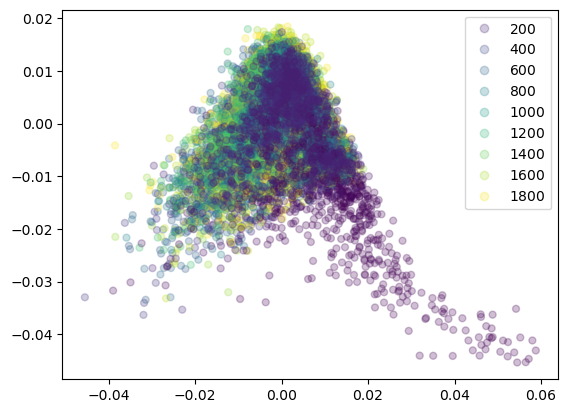

In [5]:
el = plt.scatter(*torch.pca_lowrank(llw, 2, True, 100)[0].T, c=family_freq, s=25, alpha=0.25)
plt.legend(*el.legend_elements())
plt.show()

In [ ]:
from estimate_voronoi_area import RayExitConfig, estimate_areas_ray_torch

pts = llw.clone().float().cuda()

areas = estimate_areas_ray_torch(
    pts[:512],
    RayExitConfig(
        pilot=256,
        rel_se_target=0.01,
        n_min=128,
        n_max=50_000,
        seed=0,
        batch_pilot=16,
        batch_final=16,
        device="cuda" if torch.cuda.is_available() else "cpu",
        dtype=torch.float32,
        debug_cell=0,
        out_path="test_torch.jpeg",
        plot=False,
        max_competitors=None,  # set to e.g. 256 for a fast approximate mode
    )
)

Pilot:   0%|          | 0/32 [00:00<?, ?it/s]

RuntimeError: Index tensor must have the same number of dimensions as src tensor

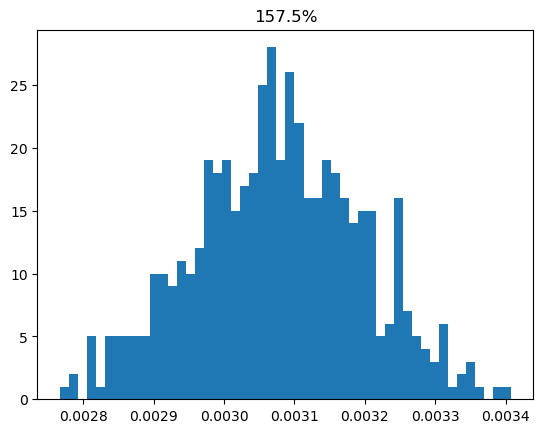

In [9]:
plt.hist(areas["proportions"], 50)
plt.title(f'{areas["proportions"].sum().item():.1%}')
plt.show()

In [16]:
idx2cls = {v : k for k, v in class_spec["cls2idx"]["0"].items()}
result = []
for i, a in enumerate(areas["proportions"].tolist()):
    c = idx2cls[i]
    result.append((c, a))

with open("areas.csv", "w") as f:
    f.write("species,area")
    for c, a in result:
        f.write(f'\n{c},{a}')

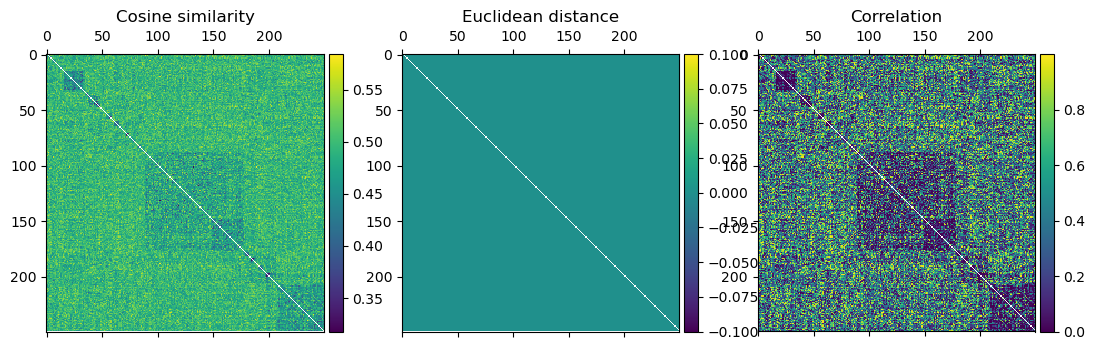

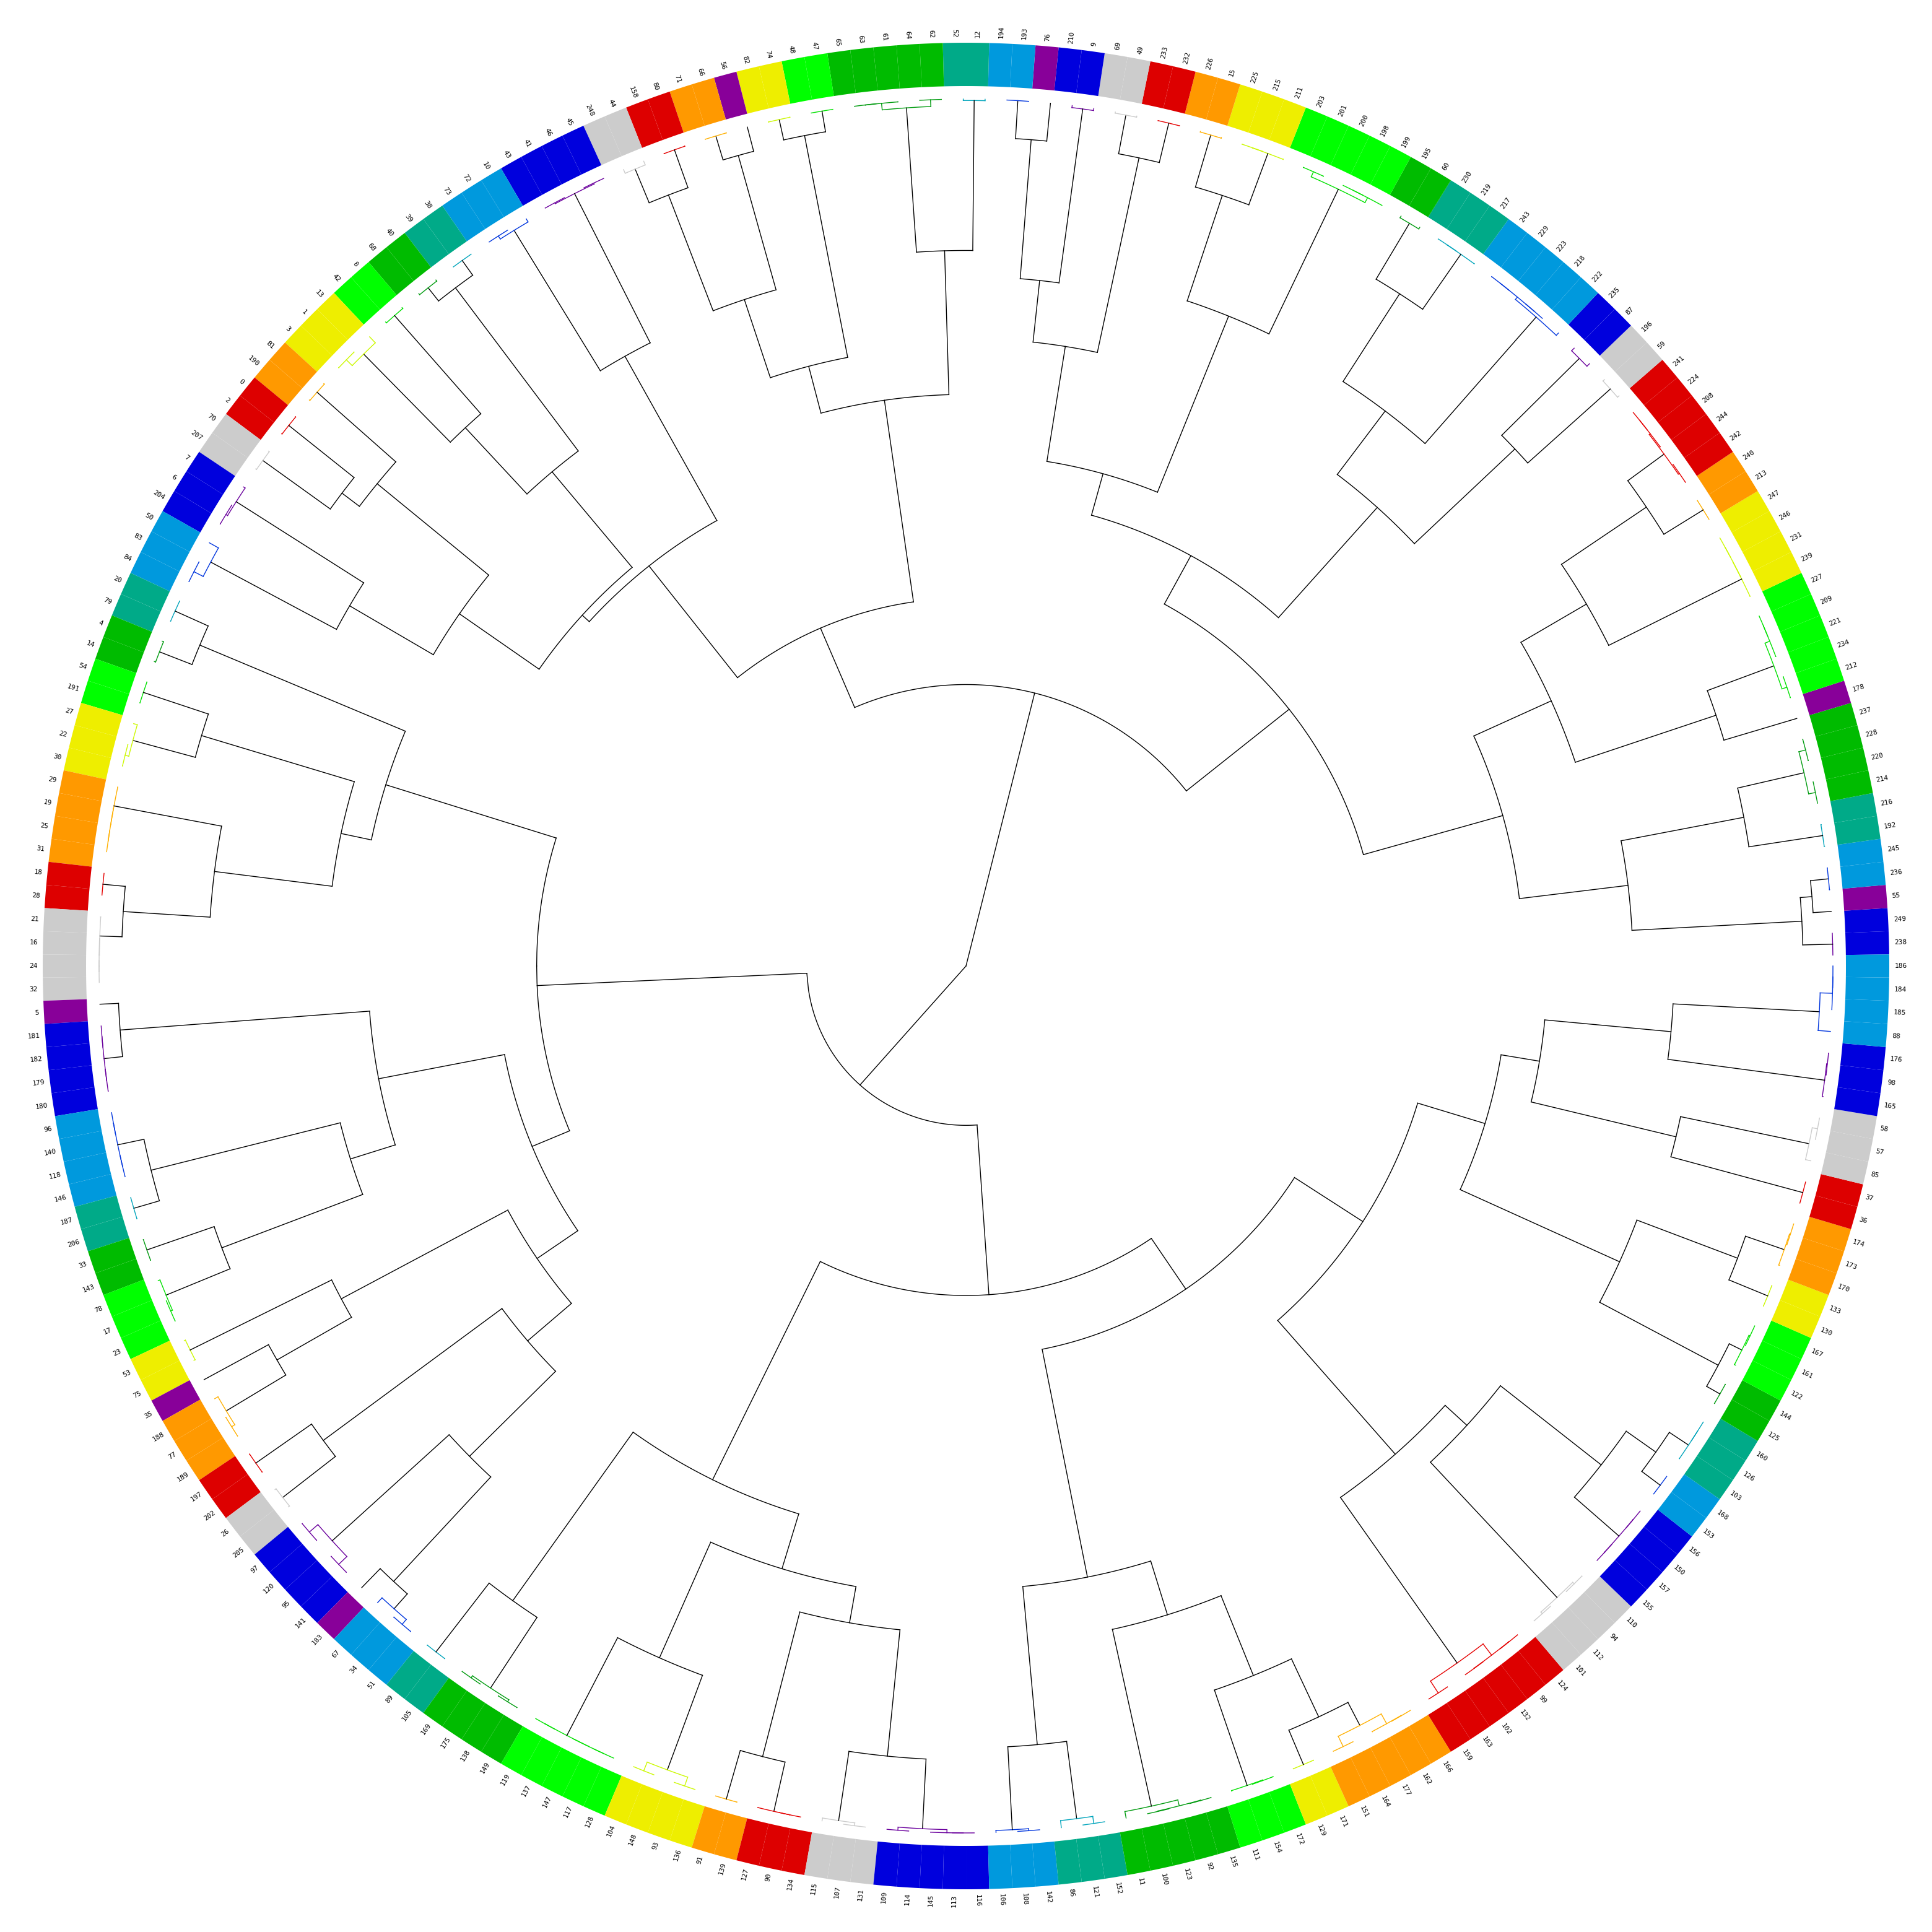

[238,
 249,
 55,
 236,
 245,
 192,
 216,
 214,
 220,
 228,
 237,
 178,
 212,
 234,
 221,
 209,
 227,
 239,
 231,
 246,
 247,
 213,
 240,
 242,
 244,
 208,
 224,
 241,
 59,
 196,
 87,
 235,
 222,
 218,
 223,
 229,
 243,
 217,
 219,
 230,
 60,
 195,
 199,
 198,
 200,
 201,
 203,
 211,
 215,
 225,
 15,
 226,
 232,
 233,
 49,
 69,
 9,
 210,
 76,
 193,
 194,
 12,
 52,
 62,
 64,
 61,
 63,
 65,
 47,
 48,
 74,
 82,
 56,
 66,
 71,
 80,
 158,
 44,
 248,
 45,
 46,
 41,
 43,
 10,
 72,
 73,
 38,
 39,
 40,
 68,
 8,
 42,
 13,
 1,
 3,
 81,
 190,
 0,
 2,
 70,
 207,
 7,
 6,
 204,
 50,
 83,
 84,
 20,
 79,
 4,
 14,
 54,
 191,
 27,
 22,
 30,
 29,
 19,
 25,
 31,
 18,
 28,
 21,
 16,
 24,
 32,
 5,
 181,
 182,
 179,
 180,
 96,
 140,
 118,
 146,
 187,
 206,
 33,
 143,
 78,
 17,
 23,
 53,
 75,
 35,
 188,
 77,
 189,
 197,
 202,
 26,
 205,
 97,
 120,
 95,
 141,
 183,
 67,
 34,
 51,
 89,
 105,
 169,
 175,
 138,
 149,
 119,
 137,
 147,
 117,
 128,
 104,
 148,
 93,
 136,
 91,
 139,
 127,
 90,
 134,
 115,
 107,
 131,


In [137]:
from plot_tree import hierarchical_cluster_llw

hierarchical_cluster_llw(llw[1000:1250], None)